<a href="https://colab.research.google.com/github/Lourdes-Churacutipa/Repositorio-de-lourdes/blob/main/EIA_Analisis_Aire_QoriWasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Línea de Base Física — Componente Aire
## Proyecto Minero Qori Wasi (Cu–Mo) · Dataset sintético con fines académicos

**Guía de Ejercicio — Semana 3 (UTEC · Ingeniería Ambiental)**

Este notebook desarrolla el análisis estadístico de la **Sección 3.3 — Calidad de Aire**
(5 años trimestrales, 4 estaciones) a partir del archivo
`UTEC_Datos_LBA_Practica_ProyectoQoriWasi.xlsx`:

1. Percentil 95 de PM10 por estación vs. ECA (D.S. N° 003-2017-MINAM, 100 µg/m³ en 24h).
2. Comparación CA-AIR-04 (referencia/fondo) vs. CA-AIR-02 (futuro tajo).
3. Serie temporal trimestral de PM10 y su relación con la estacionalidad de la precipitación
   (datos de la estación meteorológica EM-01, Sección 3.1).

> Ejecutar las celdas en orden. Diseñado para correr en **Google Colab**.


## 0. Preparación del entorno y carga de datos

In [ ]:
# Librerías necesarias (ya vienen preinstaladas en Google Colab)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Estética general de los gráficos
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [ ]:
# --- Cargar el archivo Excel en Google Colab ---
# Opción A: subir el archivo manualmente desde tu computadora
from google.colab import files
uploaded = files.upload()  # selecciona "UTEC_Datos_LBA_Practica_ProyectoQoriWasi.xlsx"

FILE_NAME = "UTEC_Datos_LBA_Practica_ProyectoQoriWasi.xlsx"

# Opción B (alternativa): si el archivo está en Google Drive, comenta la celda de arriba
# y descomenta lo siguiente:
# from google.colab import drive
# drive.mount('/content/drive')
# FILE_NAME = "/content/drive/MyDrive/RUTA/UTEC_Datos_LBA_Practica_ProyectoQoriWasi.xlsx"


Saving UTEC_Datos_LBA_Practica_ProyectoQoriWasi.xlsx to UTEC_Datos_LBA_Practica_ProyectoQoriWasi.xlsx


In [ ]:
# Cargar las hojas relevantes para el componente Aire
xls = pd.ExcelFile(FILE_NAME)

aire      = pd.read_excel(xls, "Calidad_Aire")
estaciones = pd.read_excel(xls, "Estaciones_Aire")
meteo     = pd.read_excel(xls, "Meteorología")
eca_ref   = pd.read_excel(xls, "ECA_Referencia")

print("Calidad_Aire:", aire.shape)
print("Estaciones_Aire:", estaciones.shape)
print("Meteorología:", meteo.shape)
aire.head()


Calidad_Aire: (80, 11)
Estaciones_Aire: (4, 6)
Meteorología: (720, 12)


,Estación,Año,Mes_muestreo,Temporada,PM10_ug_m3_24h,PM2.5_ug_m3_24h,SO2_ug_m3_24h,NO2_ug_m3_1h,CO_ug_m3_1h,Pb_ug_m3_mensual,Método
0,CA-AIR-01,2019,2,Húmeda,45.7,17.4,6.7,8.5,258,0.0258,Equivalente EPA (gravimétrico / quimioluminisc...
1,CA-AIR-01,2019,5,Transición,49.7,22.9,9.7,10.1,387,0.0232,Equivalente EPA (gravimétrico / quimioluminisc...
2,CA-AIR-01,2019,8,Seca,33.5,16.6,14.7,15.1,426,0.0203,Equivalente EPA (gravimétrico / quimioluminisc...
3,CA-AIR-01,2019,11,Transición,69.5,26.5,5.8,11.4,485,0.0296,Equivalente EPA (gravimétrico / quimioluminisc...
4,CA-AIR-01,2020,2,Húmeda,41.9,20.6,4.1,11.2,433,0.0168,Equivalente EPA (gravimétrico / quimioluminisc...


In [ ]:
# Estándar de Calidad Ambiental para Aire (D.S. N° 003-2017-MINAM)
ECA_PM10 = 100   # µg/m³, 24 h
ECA_PM25 = 50    # µg/m³, 24 h

# Verificamos el valor exacto registrado en la hoja ECA_Referencia (opcional, solo confirmación)
eca_aire = eca_ref[eca_ref["Matriz / Categoría"].str.contains("Aire", case=False, na=False)]
eca_aire


,Matriz / Categoría,Parámetro,Valor ECA,Norma
8,Aire,PM10 (24h),100 µg/m³,D.S. 003-2017-MINAM
9,Aire,PM2.5 (24h),50 µg/m³,D.S. 003-2017-MINAM
10,Aire,SO2 (24h),250 µg/m³,D.S. 003-2017-MINAM
11,Aire,NO2 (1h),200 µg/m³,D.S. 003-2017-MINAM
12,Aire,CO (1h),"30,000 µg/m³",D.S. 003-2017-MINAM
13,Aire,Pb (mensual),1.5 µg/m³,D.S. 003-2017-MINAM


## 1. Percentil 95 de PM10 por estación vs. ECA

El percentil 95 (P95) es el indicador estadístico que usa SENACE/MINAM para comparar
series de calidad de aire contra el ECA, ya que resume el comportamiento de "peor caso"
sin ser tan sensible a valores atípicos puntuales como el máximo absoluto.


In [ ]:
# Estadística descriptiva de PM10 por estación
resumen_pm10 = (
    aire.groupby("Estación")["PM10_ug_m3_24h"]
    .agg(n="count", media="mean", mediana="median", desv_std="std",
         minimo="min", maximo="max",
         p95=lambda x: np.percentile(x, 95))
    .round(1)
    .reset_index()
)

resumen_pm10["%_del_ECA_P95"] = (resumen_pm10["p95"] / ECA_PM10 * 100).round(1)

# Unir con el nombre/tipo de estación para mayor claridad
resumen_pm10 = resumen_pm10.merge(
    estaciones[["Código", "Nombre", "Tipo"]],
    left_on="Estación", right_on="Código"
).drop(columns="Código")

# Ordenar columnas
resumen_pm10 = resumen_pm10[["Estación", "Nombre", "Tipo", "n", "media", "mediana",
                              "desv_std", "minimo", "maximo", "p95", "%_del_ECA_P95"]]
resumen_pm10.sort_values("p95", ascending=False)


,Estación,Nombre,Tipo,n,media,mediana,desv_std,minimo,maximo,p95,%_del_ECA_P95
1,CA-AIR-02,Futuro Tajo Norte,Área del proyecto,20,47.1,42.0,17.0,27.6,88.7,79.8,79.8
0,CA-AIR-01,Campamento,Área del proyecto,20,38.5,37.8,11.8,19.6,69.5,53.1,53.1
2,CA-AIR-03,Centro Poblado Chalhuane,Receptor sensible,20,31.6,31.4,9.1,15.2,47.3,43.6,43.6
3,CA-AIR-04,Estación de Referencia (barlovento),Referencia / fondo,20,19.6,19.2,7.6,7.4,35.7,31.4,31.4


In [ ]:
# Lo mismo para PM2.5, como referencia complementaria
resumen_pm25 = (
    aire.groupby("Estación")["PM2.5_ug_m3_24h"]
    .agg(media="mean", p95=lambda x: np.percentile(x, 95))
    .round(1)
)
resumen_pm25["%_del_ECA_P95"] = (resumen_pm25["p95"] / ECA_PM25 * 100).round(1)
resumen_pm25


,media,p95,%_del_ECA_P95
Estación,,,
CA-AIR-01,17.0,25.5,51.0
CA-AIR-02,20.3,36.2,72.4
CA-AIR-03,13.8,20.2,40.4
CA-AIR-04,8.5,13.9,27.8


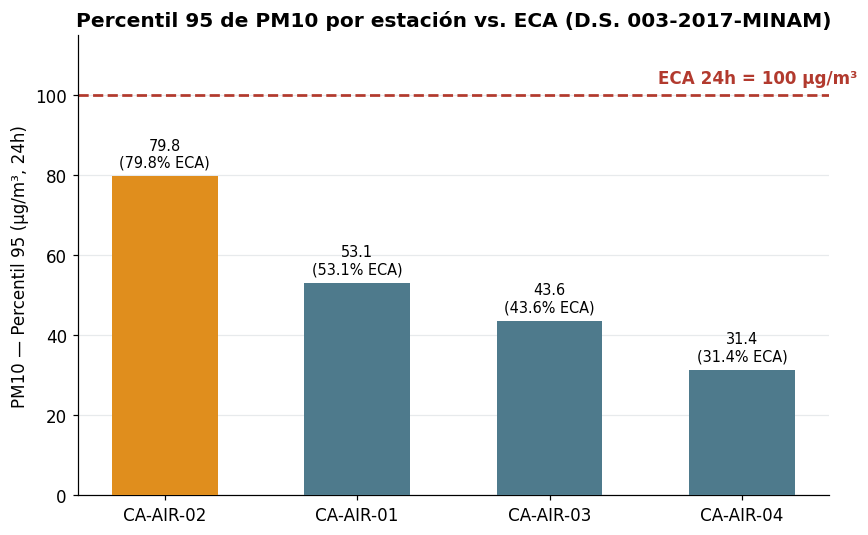

In [ ]:
# Gráfico: P95 de PM10 por estación vs. ECA
fig, ax = plt.subplots(figsize=(8, 5))

orden = resumen_pm10.sort_values("p95", ascending=False)
colores = ["#E08E1D" if v >= 70 else "#4E7A8C" for v in orden["p95"]]

barras = ax.bar(orden["Estación"], orden["p95"], color=colores, width=0.55, zorder=3)

# Línea de referencia del ECA
ax.axhline(ECA_PM10, color="#B23A2E", linestyle="--", linewidth=1.8, zorder=2)
ax.text(len(orden) - 0.4, ECA_PM10 + 2, f"ECA 24h = {ECA_PM10} µg/m³",
        color="#B23A2E", fontweight="bold", ha="right", va="bottom")

# Etiquetas de valor sobre cada barra
for b, v, pct in zip(barras, orden["p95"], orden["%_del_ECA_P95"]):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f"{v}\n({pct}% ECA)",
            ha="center", va="bottom", fontsize=9.5)

ax.set_ylim(0, ECA_PM10 * 1.15)
ax.set_ylabel("PM10 — Percentil 95 (µg/m³, 24h)")
ax.set_title("Percentil 95 de PM10 por estación vs. ECA (D.S. 003-2017-MINAM)", fontweight="bold")
ax.grid(axis="y", color="#E7EAEC", zorder=0)
plt.tight_layout()
plt.show()


In [ ]:
# Lectura automática del resultado (según los datos cargados)
estacion_critica = resumen_pm10.loc[resumen_pm10["p95"].idxmax()]
print(f"Estación más cercana al ECA: {estacion_critica['Estación']} "
      f"({estacion_critica['Nombre']}) -> P95 = {estacion_critica['p95']} µg/m³ "
      f"({estacion_critica['%_del_ECA_P95']}% del ECA)")

supera = resumen_pm10[resumen_pm10["p95"] >= ECA_PM10]
if len(supera) == 0:
    print("\nNinguna estación supera el ECA en el percentil 95.")
else:
    print("\nEstaciones que SUPERAN el ECA en el percentil 95:")
    print(supera[["Estación", "p95"]])


Estación más cercana al ECA: CA-AIR-02 (Futuro Tajo Norte) -> P95 = 79.8 µg/m³ (79.8% del ECA)

Ninguna estación supera el ECA en el percentil 95.


## 2. Comparación CA-AIR-04 (referencia/fondo) vs. CA-AIR-02 (futuro tajo)

`CA-AIR-04` es la estación de referencia (barlovento, sin influencia antrópica) y
representa la condición de "fondo" atmosférico natural. `CA-AIR-02` se ubica en la zona
del futuro tajo (área del proyecto). Comparamos ambas para evaluar si ya existe una
diferencia significativa **antes** de que la mina entre en operación.


In [ ]:
est_ref, est_proy = "CA-AIR-04", "CA-AIR-02"

comp = aire[aire["Estación"].isin([est_ref, est_proy])]

comp_stats = (
    comp.groupby("Estación")["PM10_ug_m3_24h"]
    .agg(media="mean", mediana="median", desv_std="std",
         p95=lambda x: np.percentile(x, 95))
    .round(1)
)
comp_stats


,media,mediana,desv_std,p95
Estación,,,,
CA-AIR-02,47.1,42.0,17.0,79.8
CA-AIR-04,19.6,19.2,7.6,31.4


In [ ]:
media_ref  = comp_stats.loc[est_ref, "media"]
media_proy = comp_stats.loc[est_proy, "media"]
p95_ref    = comp_stats.loc[est_ref, "p95"]
p95_proy   = comp_stats.loc[est_proy, "p95"]

ratio_media = media_proy / media_ref
ratio_p95   = p95_proy / p95_ref

print(f"Media  {est_proy}: {media_proy} µg/m³  |  Media  {est_ref}: {media_ref} µg/m³  ->  {ratio_media:.2f}x")
print(f"P95    {est_proy}: {p95_proy} µg/m³  |  P95    {est_ref}: {p95_ref} µg/m³  ->  {ratio_p95:.2f}x")


Media  CA-AIR-02: 47.1 µg/m³  |  Media  CA-AIR-04: 19.6 µg/m³  ->  2.40x
P95    CA-AIR-02: 79.8 µg/m³  |  P95    CA-AIR-04: 31.4 µg/m³  ->  2.54x


/tmp/ipykernel_858/4056642765.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot([data_ref, data_proy], labels=[f"{est_ref}\n(Referencia)", f"{est_proy}\n(Futuro Tajo)"],


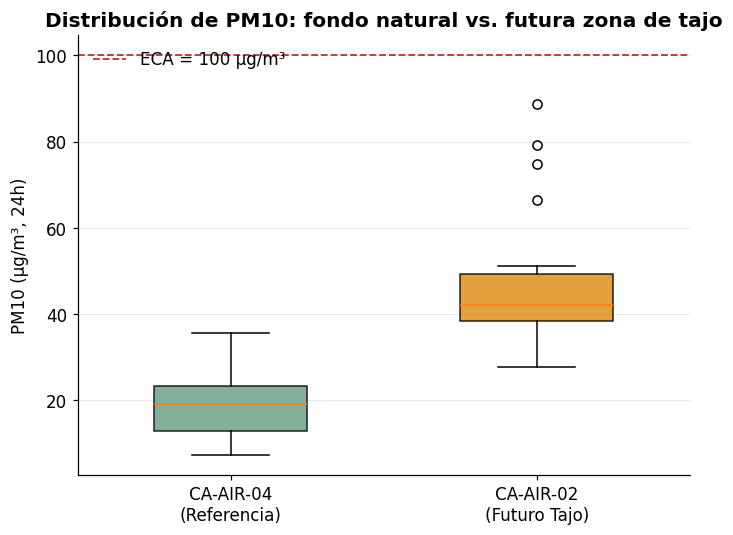

In [ ]:
# Gráfico comparativo: boxplot de distribución PM10 (CA-AIR-04 vs CA-AIR-02)
fig, ax = plt.subplots(figsize=(6.5, 5))

data_ref  = aire.loc[aire["Estación"] == est_ref,  "PM10_ug_m3_24h"]
data_proy = aire.loc[aire["Estación"] == est_proy, "PM10_ug_m3_24h"]

box = ax.boxplot([data_ref, data_proy], labels=[f"{est_ref}\n(Referencia)", f"{est_proy}\n(Futuro Tajo)"],
                  patch_artist=True, widths=0.5)

for patch, color in zip(box["boxes"], ["#6FA287", "#E08E1D"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.axhline(ECA_PM10, color="#B23A2E", linestyle="--", linewidth=1.2, label=f"ECA = {ECA_PM10} µg/m³")
ax.set_ylabel("PM10 (µg/m³, 24h)")
ax.set_title("Distribución de PM10: fondo natural vs. futura zona de tajo", fontweight="bold")
ax.legend(loc="upper left", frameon=False)
ax.grid(axis="y", color="#E7EAEC", zorder=0)
plt.tight_layout()
plt.show()


**Interpretación:** aunque el proyecto aún no ha iniciado operaciones de tajo, `CA-AIR-02`
registra niveles de PM10 sistemáticamente más altos que la estación de fondo `CA-AIR-04`
(ver los ratios calculados arriba). Esta diferencia **no puede atribuirse a la mina**, porque
todavía no opera; las explicaciones más plausibles son:

- **Actividad exploratoria en curso** (perforaciones, plataformas, accesos ya construidos).
- **Tránsito vehicular en vías no pavimentadas** hacia plataformas de exploración y campamento.
- **Remoción parcial de cobertura vegetal / suelo expuesto** en las áreas ya intervenidas.
- **Diferencias topográficas y de exposición al viento**: `CA-AIR-04` está a mayor altitud y
  a barlovento, sin fuentes locales de disturbio, mientras `CA-AIR-02` se ubica en un valle
  más expuesto a resuspensión de polvo.

Esta condición debe documentarse explícitamente en la Línea de Base para no atribuir, una vez
iniciada la operación, impactos que en realidad son preexistentes (fase exploratoria).


## 3. Serie temporal trimestral de PM10 y relación con la precipitación

Se grafica el PM10 promedio trimestral de las 4 estaciones a lo largo de 2019–2023, y se
contrasta el patrón estacional (húmeda / transición / seca) con la precipitación mensual
de la estación meteorológica **EM-01** (Sección 3.1).


In [ ]:
# Construir un identificador de periodo ordenado cronológicamente
aire_ts = aire.copy()
aire_ts["Periodo"] = pd.to_datetime(
    aire_ts["Año"].astype(str) + "-" + aire_ts["Mes_muestreo"].astype(str) + "-01"
)
aire_ts = aire_ts.sort_values("Periodo")

pivot_pm10 = aire_ts.pivot_table(index="Periodo", columns="Estación",
                                  values="PM10_ug_m3_24h", aggfunc="mean")
pivot_pm10.head()


Estación,CA-AIR-01,CA-AIR-02,CA-AIR-03,CA-AIR-04
Periodo,,,,
2019-02-01,45.7,40.7,29.7,7.4
2019-05-01,49.7,39.1,32.7,35.7
2019-08-01,33.5,36.7,47.3,27.8
2019-11-01,69.5,79.3,30.1,11.7
2020-02-01,41.9,29.8,20.7,12.2


In [ ]:
# Gráfico: serie temporal trimestral de PM10 por estación
fig, ax = plt.subplots(figsize=(11, 5.5))

colores_estacion = {
    "CA-AIR-01": "#8D775F",
    "CA-AIR-02": "#E08E1D",
    "CA-AIR-03": "#4E7A8C",
    "CA-AIR-04": "#6FA287",
}

for est in pivot_pm10.columns:
    ax.plot(pivot_pm10.index, pivot_pm10[est], marker="o", markersize=4,
            linewidth=1.8, label=est, color=colores_estacion.get(est))

ax.axhline(ECA_PM10, color="#B23A2E", linestyle="--", linewidth=1.2)
ax.text(pivot_pm10.index[-1], ECA_PM10 + 1.5, f"ECA 24h = {ECA_PM10} µg/m³",
        color="#B23A2E", ha="right", va="bottom", fontweight="bold", fontsize=9)

ax.set_ylabel("PM10 (µg/m³, 24h)")
ax.set_title("PM10 promedio trimestral por estación (2019–2023)", fontweight="bold")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.15), frameon=False)
ax.grid(axis="y", color="#E7EAEC")
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Precipitación mensual promedio (2004-2023) de la estación EM-01
em01 = meteo[meteo["Estación"] == "EM-01"]
precip_por_mes = em01.groupby("Mes")["Precipitación_mensual_mm"].mean().round(1)

# Los muestreos de aire se realizan en los meses 2, 5, 8 y 11
meses_muestreo = {2: "Húmeda (feb)", 5: "Transición (may)", 8: "Seca (ago)", 11: "Transición (nov)"}
precip_muestreo = precip_por_mes.loc[list(meses_muestreo.keys())]
precip_muestreo.index = precip_muestreo.index.map(meses_muestreo)
precip_muestreo


,Precipitación_mensual_mm
Mes,
Húmeda (feb),121.2
Transición (may),31.5
Seca (ago),9.9
Transición (nov),83.0


In [ ]:
# PM10 promedio por temporada (todas las estaciones) y precipitación asociada
pm10_por_temporada = aire.groupby("Temporada")["PM10_ug_m3_24h"].mean().round(1)

precip_por_temporada = pd.Series({
    "Húmeda":     precip_por_mes[2],
    "Transición": (precip_por_mes[5] + precip_por_mes[11]) / 2,
    "Seca":       precip_por_mes[8],
}).round(1)

orden_temporada = ["Húmeda", "Transición", "Seca"]
pm10_por_temporada = pm10_por_temporada.reindex(orden_temporada)
precip_por_temporada = precip_por_temporada.reindex(orden_temporada)

tabla_estacional = pd.DataFrame({
    "PM10_promedio_ug_m3": pm10_por_temporada,
    "Precipitacion_media_mm": precip_por_temporada,
})
tabla_estacional


,PM10_promedio_ug_m3,Precipitacion_media_mm
Húmeda,27.0,121.2
Transición,34.7,57.2
Seca,40.5,9.9


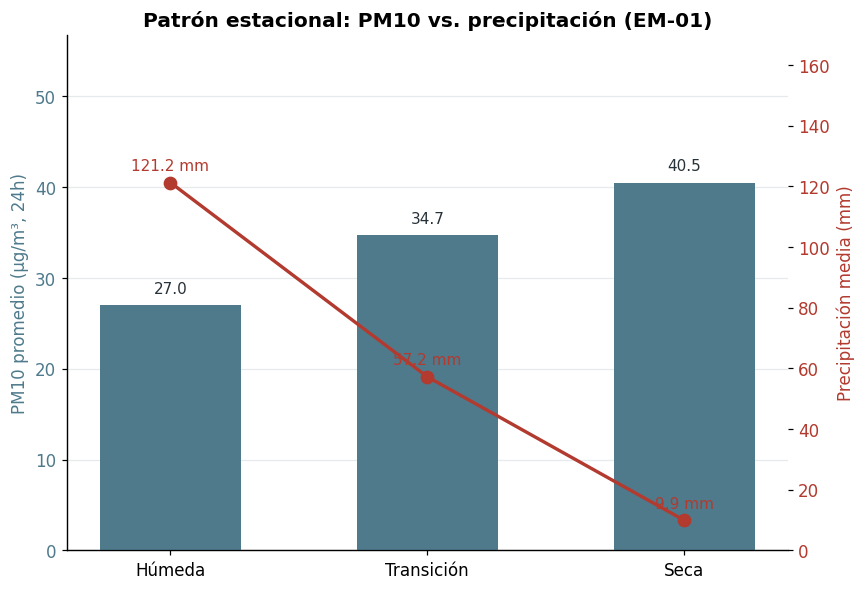

In [ ]:
# Gráfico combinado: PM10 (barras) vs. Precipitación (línea) por temporada
fig, ax1 = plt.subplots(figsize=(8, 5.5))

ax1.bar(orden_temporada, pm10_por_temporada.values, color="#4E7A8C", width=0.55, zorder=3,
        label="PM10 promedio (µg/m³)")
ax1.set_ylabel("PM10 promedio (µg/m³, 24h)", color="#4E7A8C")
ax1.tick_params(axis="y", labelcolor="#4E7A8C")
ax1.set_ylim(0, max(pm10_por_temporada.values) * 1.4)

for i, v in enumerate(pm10_por_temporada.values):
    ax1.text(i, v + 1, f"{v}", ha="center", va="bottom", color="#263238", fontsize=10)

ax2 = ax1.twinx()
ax2.plot(orden_temporada, precip_por_temporada.values, color="#B23A2E",
         marker="o", markersize=8, linewidth=2.2, label="Precipitación media (mm)")
ax2.set_ylabel("Precipitación media (mm)", color="#B23A2E")
ax2.tick_params(axis="y", labelcolor="#B23A2E")
ax2.set_ylim(0, max(precip_por_temporada.values) * 1.4)

for i, v in enumerate(precip_por_temporada.values):
    ax2.text(i, v + 3, f"{v} mm", ha="center", va="bottom", color="#B23A2E", fontsize=10)

ax1.set_title("Patrón estacional: PM10 vs. precipitación (EM-01)", fontweight="bold")
ax1.grid(axis="y", color="#E7EAEC", zorder=0)
fig.tight_layout()
plt.show()


In [ ]:
# Correlación simple entre precipitación y PM10 a nivel de temporada
correlacion = tabla_estacional["PM10_promedio_ug_m3"].corr(tabla_estacional["Precipitacion_media_mm"])
print(f"Correlación PM10 vs. precipitación (por temporada): r = {correlacion:.2f}")

# PM10 por estación y temporada (para ver si el patrón se repite en las 4 estaciones)
pm10_est_temporada = aire.pivot_table(index="Estación", columns="Temporada",
                                       values="PM10_ug_m3_24h", aggfunc="mean").round(1)
pm10_est_temporada = pm10_est_temporada[["Húmeda", "Transición", "Seca"]]
pm10_est_temporada


Correlación PM10 vs. precipitación (por temporada): r = -1.00


Temporada,Húmeda,Transición,Seca
Estación,,,
CA-AIR-01,35.2,38.5,41.8
CA-AIR-02,38.7,46.7,56.3
CA-AIR-03,22.8,32.4,38.9
CA-AIR-04,11.2,21.0,25.1


**Interpretación:** existe una **relación inversa clara** entre la precipitación y el PM10:
la época seca (menor precipitación, ~10 mm/mes en EM-01) coincide con el PM10 más alto en
las **cuatro** estaciones, mientras que la época húmeda (~121 mm/mes) presenta los valores
más bajos. Esto es consistente con el efecto de "lavado atmosférico" de la lluvia, que
suprime la resuspensión y el transporte de material particulado.

Este patrón estacional es una **fuente de variabilidad natural** que debe diferenciarse
claramente de cualquier futura señal de impacto asociada a la operación minera: un
incremento de PM10 en época seca, por sí solo, no debería interpretarse como un impacto del
proyecto si ya se observa el mismo comportamiento en la estación de referencia (`CA-AIR-04`).


## 4. Resumen ejecutivo (generado a partir de los cálculos anteriores)

In [ ]:
print("="*70)
print("RESUMEN — COMPONENTE AIRE (PM10)")
print("="*70)

print(f"\n1) Percentil 95 de PM10 vs. ECA ({ECA_PM10} µg/m³, 24h):")
for _, row in resumen_pm10.sort_values('p95', ascending=False).iterrows():
    print(f"   - {row['Estación']} ({row['Nombre']}): P95 = {row['p95']} µg/m³ "
          f"({row['%_del_ECA_P95']}% del ECA)")

print(f"\n2) {est_proy} (futuro tajo) vs. {est_ref} (referencia):")
print(f"   - Media: {ratio_media:.2f}x más alta en {est_proy}")
print(f"   - P95:   {ratio_p95:.2f}x más alta en {est_proy}")
print("   -> Diferencia atribuible a actividad exploratoria/accesos preexistentes,")
print("      no a la operación minera (aún no iniciada).")

print(f"\n3) Patrón estacional (correlación PM10 vs. precipitación): r = {correlacion:.2f}")
print("   -> A menor precipitación (época seca), mayor PM10 en las 4 estaciones:")
print("      variabilidad natural que debe distinguirse de futuros impactos del proyecto.")


RESUMEN — COMPONENTE AIRE (PM10)

1) Percentil 95 de PM10 vs. ECA (100 µg/m³, 24h):
   - CA-AIR-02 (Futuro Tajo Norte): P95 = 79.8 µg/m³ (79.8% del ECA)
   - CA-AIR-01 (Campamento): P95 = 53.1 µg/m³ (53.1% del ECA)
   - CA-AIR-03 (Centro Poblado Chalhuane): P95 = 43.6 µg/m³ (43.6% del ECA)
   - CA-AIR-04 (Estación de Referencia (barlovento)): P95 = 31.4 µg/m³ (31.4% del ECA)

2) CA-AIR-02 (futuro tajo) vs. CA-AIR-04 (referencia):
   - Media: 2.40x más alta en CA-AIR-02
   - P95:   2.54x más alta en CA-AIR-02
   -> Diferencia atribuible a actividad exploratoria/accesos preexistentes,
      no a la operación minera (aún no iniciada).

3) Patrón estacional (correlación PM10 vs. precipitación): r = -1.00
   -> A menor precipitación (época seca), mayor PM10 en las 4 estaciones:
      variabilidad natural que debe distinguirse de futuros impactos del proyecto.
